In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vijayuv/onlineretail/OnlineRetail.csv


# Customer Segmentation Analysis using K-Means Clustering

## OIBSIP Data Analytics Internship

### Objective

The objective of this project is to segment customers based on their purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering. The identified customer groups can help businesses design targeted marketing strategies and improve customer retention.

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. RFM Feature Engineering
6. Feature Scaling
7. Elbow Method
8. K-Means Clustering
9. Cluster Visualization
10. Cluster Profiling
11. Marketing Recommendations
12. Conclusion

In [2]:
# Load Dataset

df = pd.read_csv("/kaggle/input/datasets/vijayuv/onlineretail/OnlineRetail.csv", encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Dataset Information

The Online Retail dataset contains transactions made by customers of a UK-based online retail store.

Important columns:

- InvoiceNo
- StockCode
- Description
- Quantity
- InvoiceDate
- UnitPrice
- CustomerID
- Country

In [3]:
# Dataset Overview

print("Shape of Dataset:", df.shape)
df.info()
df.describe()
df.isnull().sum()

Shape of Dataset: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [3]:
# Missing Value Handling

df = df.dropna(subset=['CustomerID'])

df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [4]:
# Duplicate Removal

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("After Removing:", df.duplicated().sum())

Duplicate Rows: 5225
After Removing: 0


In [5]:
# Convert Date Column

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
#  Create Total Amount

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [8]:
#  Descriptive Statistics

# Average Purchase Value
df['TotalAmount'].mean()

# Purchase Frequency
df.groupby('CustomerID')['InvoiceNo'].nunique().mean()

# Average Customer Lifetime Value
df.groupby('CustomerID')['TotalAmount'].sum().mean()

np.float64(1893.5314327538883)

__RFM features:__

Recency → How recently the customer made a purchase.
Frequency → How many purchases the customer made.
Monetary → Total amount the customer spent.

In [9]:
# Find the latest purchase date

# Latest date in the dataset
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [10]:
# Create the RFM Table

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,    # x.max() --> latest purchase 
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [11]:
rfm.shape

(4372, 3)

In [12]:
#  Data Normalization (StandardScaler)

# Data Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[ 2.32202285, -0.32936215, -0.23041952],
       [-0.89373323,  0.20610242,  0.29405454],
       [-0.1691956 , -0.11517632, -0.01171748],
       [-0.72500529, -0.43645506, -0.01654727],
       [ 2.16322008, -0.43645506, -0.18972715]])

# OBSERVATION
__1. fit()__

Calculates:

Mean

Standard deviation


__2. transform()__

Uses the formula


z = x−μ/σ

where

x = current value
μ = mean
σ = standard deviation

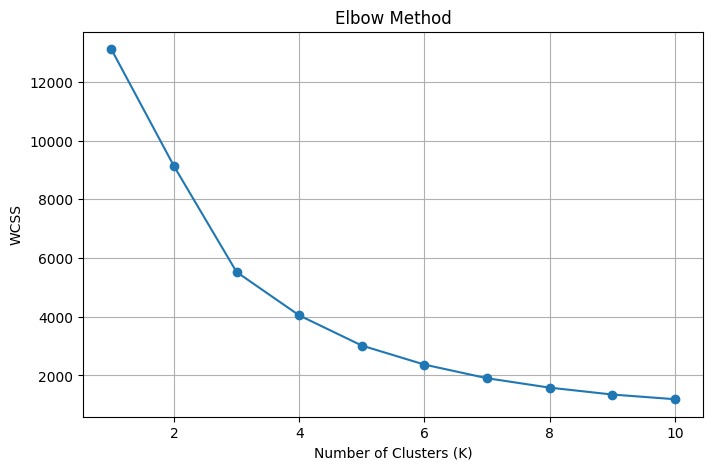

In [13]:
# Find the Best Number of Clusters (Elbow Method)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# OBSERVATION

__What is WCSS?__

WCSS = Within Cluster Sum of Squares

It measures how close the points are to the center (centroid) of their cluster.

Lower WCSS = tighter, better clusters.
As K increases, WCSS always decreases.
We choose the point where the decrease starts slowing down—that bend is the elbow.

Think of it like this:

K = 1 → One big cluster (very high WCSS)
K = 2 → Better
K = 3 → Better
K = 4 → Better
K = 5 → Improvement becomes much smaller

That "bend" is usually the best choice.

So we'll choose:
optimal_k = 4

In [14]:
# Apply K-Means Clustering

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)           # rfm["Cluster"] --> Adds a new column 

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


# OBSERVATION

__First: fit()__

The algorithm studies your data.

It tries to find 4 centroids.

Imagine placing 4 flags among 4372 customers.

Initially the flags are random.

Then repeatedly:

Assign every customer to the nearest flag.
Move each flag to the average location of its assigned customers.
Repeat until the flags stop moving.

Those final flag positions are called centroids.


__Second: predict()__

Once centroids are fixed,

every customer is assigned to the nearest centroid.

In [15]:
# Check How Many Customers Are in Each Cluster

rfm["Cluster"].value_counts().sort_index()

Cluster
0    3169
1    1087
2       6
3     110
Name: count, dtype: int64

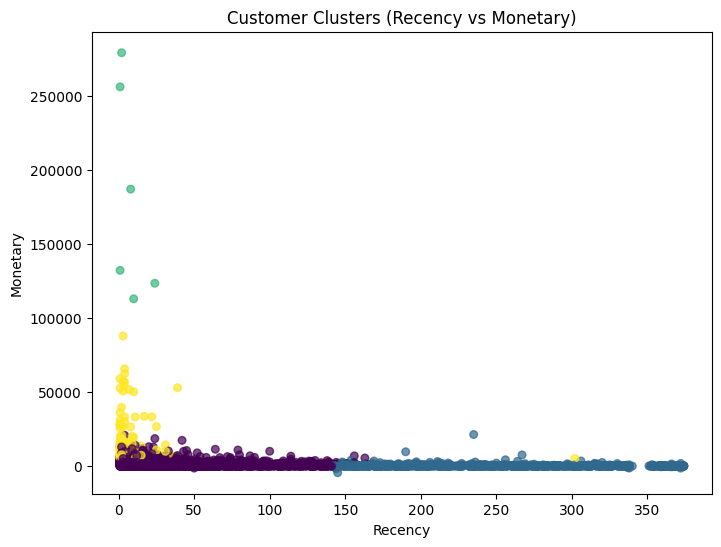

In [21]:
# Visualize the Clusters

# Scatter Plot 1
plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    s=30,
    alpha=0.7
)

plt.title("Customer Clusters (Recency vs Monetary)")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()


# OBSERVATION

Each dot is one customer.

Its position is:
X-axis → Recency

Y-axis → Monetary

Its colour represents the cluster.

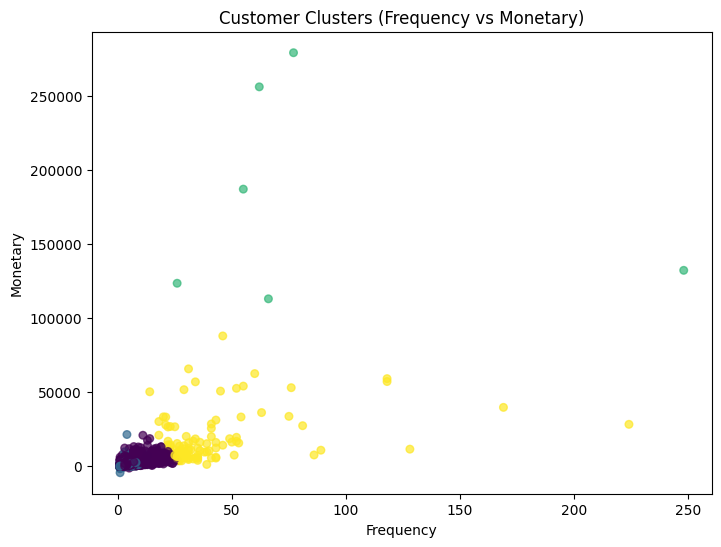

In [22]:
# Scatter Plot 2

plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    s=30,
    alpha=0.7
)

plt.title("Customer Clusters (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

In [18]:
# Profile Each Cluster

cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,41.606500,4.802461,1472.653251
1,247.951242,1.805888,451.802991
2,7.666667,89.000000,182108.075000
3,9.181818,40.672727,18435.663364


# OBSERVSATION
__This table is the heart of customer segmentation, because it tells us what each customer group looks like.__

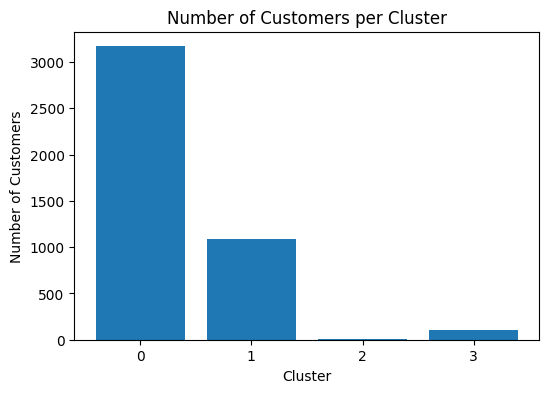

In [20]:
# Number of Customers per Cluster (Bar Chart)

import matplotlib.pyplot as plt

cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

# Marketing Recommendations

__Insights and Marketing Recommendations__

1. Cluster 0 – Loyal Customers

-> Purchase frequently and spend a good amount.

-> Reward them with loyalty programs and exclusive discounts to retain them.

2. Cluster 1 – Lost Customers

-> Long time since last purchase.
-> Encourage them to return using win-back campaigns, email reminders, and special offers.

3. Cluster 2 – VIP Customers
   
-> Highest purchase frequency and highest spending.
-> Provide premium membership, early product access, and personalized offers to maintain engagement.

4. Cluster 3 – Potential Customers

->Recently purchased but have low frequency.
->Encourage repeat purchases using personalized recommendations and limited-time discounts.

# Conclusion

Customer segmentation using RFM analysis and K-Means clustering successfully divided customers into four distinct groups based on purchasing behaviour.

The analysis identified Loyal Customers, Lost Customers, VIP Customers, and Potential Customers. These customer segments can help businesses design targeted marketing campaigns, improve customer retention, and maximize revenue through personalized strategies.

Overall, clustering provides valuable insights that support data-driven business decisions.